## 30 June 2026
## Sapkas Michail
### Lunar Lander - Final Project for Deep Neural Networks
Implement the 
# Proximal Policy Optimization (PPO) algorithm
- using the Generalized Advantage Estimation (GAE) method.

In [1]:
import torch
import random
from collections import deque
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import time
from torch.distributions import Normal

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")  # For Mac Apple Silicon users
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


Defining all the hyperparameters of the algorithm: 

- **CRITIC/ACTOR LATENT_DIM** is the dimension of the hidden layer of the neural network
- **BATCH_SIZE** is the number of samples randomly sampled from the replay buffer to train the network
- **LEARNING_RATE CRITIC/ACTOR** is self explanatory. I am using adam
- **GAMMA** is the discount factor for future rewards (in this context, because it is multiplying the estimated future rewards Q it can also represent the "trust" or "importance" of our estimation)
- **GAE_LAMBDA** controls the lambda parameter in the Generalized Advantage Estimation. High lambda will give more "trust" in the future rewards. 
- **CLIP_EPSILON** how much slack we allow to the clipping of the objective function
- **MAX_GRAD_NORM** this is clips the gradients during Neural Network training
- **ALPHA** controls how much entropy we are pumping into the system. it is basically an exploration parameter.
- **HORIZON** how many steps to take before starting Neural Network training. After this, discard the horizon and sample a completely new set
- **PPO_EPOCHS** how many times to train on **BATCH_SIZE**s over a **HORIZON**
- **N_CONSECUTIVE** is the number of consecutive episodes that the 100-episode average must stay above 200 for the environment to be considered solved

In [ ]:
ACTOR_LATENT_DIM = CRITIC_LATENT_DIM = 64
BATCH_SIZE = 32
LR_ACTOR = 1e-4
LR_CRITIC = 1e-3

GAMMA = 0.99
GAE_LAMBDA = 0.95
CLIP_EPSILON = 0.2
MAX_GRAD_NORM = 0.5
ALPHA = 1e-3

HORIZON = 2048
PPO_EPOCHS = 10

N_CONSECUTIVE = 10

The Actor Neural Net is very special in PPO. It is composed by:
- A Linear Layer that takes as input the state vector
- And a second Linear Layer that maps the 8 vector to the latent space of the network

From here, now to separate "heads" are connected:
- One outputs the mean of a gaussian distribution
- The other one outputs the log of the std (basically a number that we are going to exponentiate). Additionally this number is bound between -20 and 2 to preserve stability.

Finally the actor network draws from the gaussian distribution with mean and std and outputs an Action. This makes our actions stochastic.

The Critic Network is the same as the DDPG. Will estimate the cumulative future value of the action that the Actor took.

In [ ]:
OBSERVATION_SPACE = 8
ACTION_SPACE = 2

class Actor(nn.Module):
    def __init__(self):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(OBSERVATION_SPACE, ACTOR_LATENT_DIM),
            nn.ReLU(),
            nn.Linear(ACTOR_LATENT_DIM, ACTOR_LATENT_DIM),
            nn.ReLU()
        )
        self.mu_layer = nn.Linear(ACTOR_LATENT_DIM, ACTION_SPACE)
        self.log_std_layer = nn.Linear(ACTOR_LATENT_DIM, ACTION_SPACE)

    def forward(self, state):
        shared_features = self.shared(state)
        mu = torch.tanh(self.mu_layer(shared_features))
        
        # Calculate state-dependent log_std
        log_std = self.log_std_layer(shared_features)
        
        # Optional but highly recommended: Clamp log_std to prevent exp() from exploding
        # or collapsing to 0 due to extreme extreme state inputs early in training.
        log_std = torch.clamp(log_std, min=-20, max=2)
        std = torch.exp(log_std)
        return Normal(mu, std)

class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(OBSERVATION_SPACE, CRITIC_LATENT_DIM),
            nn.ReLU(),
            nn.Linear(CRITIC_LATENT_DIM, CRITIC_LATENT_DIM),
            nn.ReLU(),
            nn.Linear(CRITIC_LATENT_DIM, 1)
        )
        
    def forward(self, state):
        return self.network(state)

### collect_rollout

This function is the PPO analogue of a replay buffer. It IS basically a replay buffer of step granularity but with a fixed horizon. It contains a lot of functionality that previously was included in the outer "environment" loop, meaning that the check "if done", if an episode terminates, happens here.

The idea is actually simple:

- We have a fixed horizon so we know exactly how many steps we will hold in our lists of states, actions, log of probability, rewards, dones and values.
- next_obs

In [ ]:
def collect_rollout(env, actor, critic, horizon, next_obs, next_done, episode_rewards, moving_avg_rewards, current_ep_reward, pbar, N_CONSECUTIVE):
    """Collects transitions from the environment for a fixed horizon."""
    global consecutive_solved_episodes, solved
    actor.eval()
    critic.eval()

    states, actions, log_probs, rewards, dones, values = [], [], [], [], [], []

    for _ in range(horizon):
        pbar.update(1)  # <--- Move the update here so it increments smoothly per environment step!
        
        states.append(next_obs.cpu().numpy().flatten())
        dones.append(next_done.item())

        with torch.no_grad():
            dist = actor(next_obs)
            action = dist.sample()
            log_prob = dist.log_prob(action).sum(dim=-1)
            value = critic(next_obs)

        actions.append(action.cpu().numpy().flatten())
        log_probs.append(log_prob.item())
        values.append(value.item())

        env_action = np.clip(action.cpu().numpy().flatten(), -1.0, 1.0)
        next_obs_raw, reward, terminated, truncated, _ = env.step(env_action)
        
        current_ep_reward += reward
        rewards.append(reward)
        
        next_obs = torch.FloatTensor(next_obs_raw).to(device).unsqueeze(0)
        done = terminated or truncated
        next_done = torch.tensor(done, dtype=torch.float32).to(device)

        if done:
            episode_rewards.append(current_ep_reward)
            avg_100 = np.mean(episode_rewards[-100:])
            moving_avg_rewards.append(avg_100)

            if len(episode_rewards) >= 100 and avg_100 >= 200.0:
                consecutive_solved_episodes += 1
            else:
                consecutive_solved_episodes = 0

            pbar.set_postfix({
                "Ep": len(episode_rewards),
                "Last Ep Reward": f"{current_ep_reward:.1f}",
                "Alpha": f"{ALPHA:.4f}",
                "100-Ep Avg": f"{avg_100:.1f}", 
                "Hold": f"{consecutive_solved_episodes}/{N_CONSECUTIVE}"
            })

            if consecutive_solved_episodes >= N_CONSECUTIVE:
                solved = True

            current_ep_reward = 0
            next_obs_raw, _ = env.reset()
            next_obs = torch.FloatTensor(next_obs_raw).to(device).unsqueeze(0)
            
            if solved:
                break

    return (np.array(states), np.array(actions), np.array(log_probs), 
            np.array(rewards), np.array(dones), np.array(values), 
            next_obs, next_done, current_ep_reward)

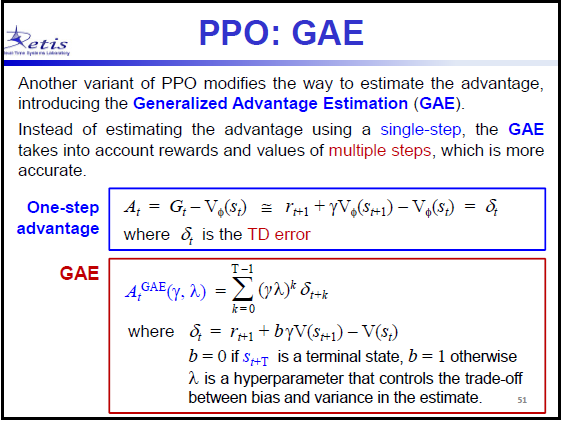

In [6]:
# --- GAE COMPUTATION ---
def compute_gae(rewards, dones, values, next_value):
    """Generalized Advantage Estimation calculation."""
    advantages = []
    gae = 0
    for i in reversed(range(len(rewards))):
        if i == len(rewards) - 1:
            next_non_terminal = 1.0 - dones[i]
            delta = rewards[i] + GAMMA * next_value * next_non_terminal - values[i]
        else:
            next_non_terminal = 1.0 - dones[i]
            delta = rewards[i] + GAMMA * values[i+1] * next_non_terminal - values[i]
        
        gae = delta + GAMMA * GAE_LAMBDA * next_non_terminal * gae
        advantages.insert(0, gae)
    
    returns = np.array(advantages) + np.array(values)
    return np.array(advantages), returns

In [7]:
# --- TRAINING STEP ---
def train_ppo(actor, critic, actor_opt, critic_opt, loss_fn, b_states, b_actions, b_log_probs, b_advantages, b_returns):
    """Optimizes actor and critic networks using mini-batches."""
    actor.train()
    critic.train()
    
    dataset_size = len(b_states)
    b_inds = np.arange(dataset_size)
    
    for epoch in range(PPO_EPOCHS):
        np.random.shuffle(b_inds)
        for start in range(0, dataset_size, BATCH_SIZE):
            mb_inds = b_inds[start:start + BATCH_SIZE]

            states = torch.FloatTensor(b_states[mb_inds]).to(device)
            actions = torch.FloatTensor(b_actions[mb_inds]).to(device)
            old_log_probs = torch.FloatTensor(b_log_probs[mb_inds]).to(device)
            returns = torch.FloatTensor(b_returns[mb_inds]).to(device)
            
            mb_advantages = b_advantages[mb_inds]
            mb_advantages = (mb_advantages - mb_advantages.mean()) / (mb_advantages.std() + 1e-8)
            advantages = torch.FloatTensor(mb_advantages).to(device)

            dist = actor(states)
            new_log_probs = dist.log_prob(actions).sum(dim=-1)
            entropy = dist.entropy().sum(dim=-1).mean()
            current_values = critic(states).squeeze(-1)

            ratios = torch.exp(new_log_probs - old_log_probs)
            surr1 = ratios * advantages
            surr2 = torch.clamp(ratios, 1.0 - CLIP_EPSILON, 1.0 + CLIP_EPSILON) * advantages
            actor_loss = -torch.min(surr1, surr2).mean() - ALPHA * entropy

            critic_loss = loss_fn(current_values, returns)

            # Optimize Actor
            actor_opt.zero_grad()
            actor_loss.backward()
            nn.utils.clip_grad_norm_(actor.parameters(), MAX_GRAD_NORM)
            actor_opt.step()

            # Optimize Critic
            critic_opt.zero_grad()
            critic_loss.backward()
            nn.utils.clip_grad_norm_(critic.parameters(), MAX_GRAD_NORM)
            critic_opt.step()

In [ ]:
# --- MAIN EXECUTION ---
env = gym.make("LunarLander-v3", continuous=True)

actor = Actor().to(device)
critic = Critic().to(device)
actor_optimizer = optim.Adam(actor.parameters(), lr=LR_ACTOR, eps=1e-5)
critic_optimizer = optim.Adam(critic.parameters(), lr=LR_CRITIC, eps=1e-5)
loss_fn = nn.MSELoss()

observation, info = env.reset(seed=42)
next_obs = torch.FloatTensor(observation).to(device).unsqueeze(0)
next_done = torch.tensor(0.0, dtype=torch.float32).to(device)

episode_rewards = []
moving_avg_rewards = []
alphas = []
current_episode_reward = 0

solved = False
consecutive_solved_episodes = 0
total_steps = 0  

print("Initializing training loop...", flush=True)
# Added miniters=1 and mininterval=0 to force visual terminal updates
pbar = tqdm(desc="Total Steps", leave=True, miniters=1, mininterval=0)

while not solved:
    total_steps += HORIZON  
    
    # 1. Collect Rollout (pbar updates smoothly inside here now)
    (states_buf, actions_buf, log_probs_buf, rewards_buf, 
        dones_buf, values_buf, next_obs, next_done, 
        current_episode_reward) = collect_rollout(
        env, actor, critic, HORIZON, next_obs, next_done, 
        episode_rewards, moving_avg_rewards, current_episode_reward, pbar, N_CONSECUTIVE
    )
    
    if solved:
        print(f"\n\nEnvironment solved permanently! 100-Ep Avg held >= 200 for {N_CONSECUTIVE} consecutive episodes.")
        break
    
    # 2. Get Next Value for GAE Bootstrap
    with torch.no_grad():
        next_value = critic(next_obs).item()
    
    # 3. Compute Advantages
    b_advantages, b_returns = compute_gae(rewards_buf, dones_buf, values_buf, next_value)
    
    # 4. Train Networks
    # Inside your training loop:
    train_ppo(
        actor, critic, actor_optimizer, critic_optimizer, loss_fn,
        states_buf, actions_buf, log_probs_buf, b_advantages, b_returns)

pbar.close()
env.close()
print(f"\nTotal environment steps taken: {total_steps:,}")
print("Environment safely closed.")

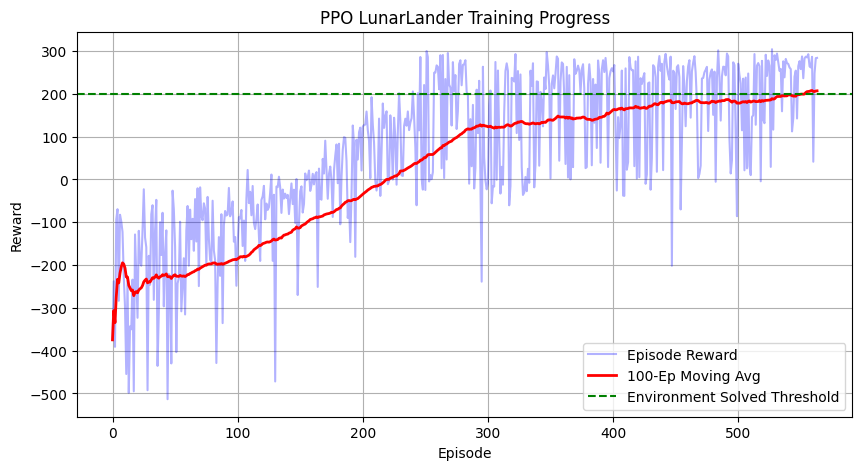

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(episode_rewards, alpha=0.3, color="blue", label="Episode Reward")
if moving_avg_rewards:
    # Handle padding the moving average mapping back to global episodes
    x_ticks = range(len(episode_rewards) - len(moving_avg_rewards), len(episode_rewards))
    plt.plot(list(x_ticks), moving_avg_rewards, color="red", linewidth=2, label="100-Ep Moving Avg")
plt.axhline(y=200, color="green", linestyle="--", label="Environment Solved Threshold")
plt.title("PPO LunarLander Training Progress")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.grid(True)
plt.savefig("ppo_lunar_lander_progress.png")
plt.show()

In [10]:
# Save weights
torch.save(actor.state_dict(), "ppo_actor_lunar_lander.pth")
print("Actor model saved to ppo_actor_lunar_lander.pth")

Actor model saved to ppo_actor_lunar_lander.pth


In [11]:
# Initialize and load weights
test_actor = Actor().to(device)
test_actor.load_state_dict(torch.load("ppo_actor_lunar_lander.pth", map_location=device))
test_actor.eval()  # Set network to evaluation mode

# Determine the device the actor is currently living on
current_device = next(test_actor.parameters()).device

# Initialize environment in "human" render mode with continuous action space
env = gym.make("LunarLander-v3", continuous=True, render_mode="human")

# Run for 5 demonstration episodes
NUM_EPISODES = 5

for episode in range(NUM_EPISODES):
    observation, info = env.reset()
    episode_reward = 0
    done = False

    print(f"Starting PPO Evaluation Episode {episode + 1}...")

    while not done:
        # Convert observation to tensor and send it to the actor's current device
        state_tensor = torch.FloatTensor(observation).unsqueeze(0).to(current_device)

        # Pure Exploitation: Extract the mean (mu) from the policy's Normal distribution
        with torch.no_grad():
            dist = test_actor(state_tensor)
            # dist.mean represents the absolute best guess of the policy without exploration noise
            action = dist.mean.squeeze(0).cpu().numpy()

        # Step the environment with continuous controls clipped to valid bounds
        env_action = np.clip(action, -1.0, 1.0)
        observation, reward, terminated, truncated, info = env.step(env_action)
        done = terminated or truncated
        episode_reward += reward

        # Small sleep delay so the human eye can track the smooth engine firing
        time.sleep(0.01)

    print(f"Episode {episode + 1} Finished! Total Reward: {episode_reward:.1f}\n")

env.close()
print("Evaluation Complete!")

Starting PPO Evaluation Episode 1...
Episode 1 Finished! Total Reward: 260.9

Starting PPO Evaluation Episode 2...
Episode 2 Finished! Total Reward: 284.3

Starting PPO Evaluation Episode 3...
Episode 3 Finished! Total Reward: 233.9

Starting PPO Evaluation Episode 4...
Episode 4 Finished! Total Reward: 276.4

Starting PPO Evaluation Episode 5...
Episode 5 Finished! Total Reward: 281.5

Evaluation Complete!


# Code for stability analysis
### 10 Runs of PPO with different random seeds

In [8]:
import os
# --- Hyperparameters / Setup Assumptions ---
TOTAL_TIMESTEPS = 300000
N_RUNS = 10
SAVE_DIR = "./PPO_stability_analysis"
os.makedirs(SAVE_DIR, exist_ok=True)

all_runs_logs = []         # Holds the logged 100-ep moving avg rewards for each run
all_runs_lengths_logs = []  # Holds the logged final episode count for each run

print(f"Starting PPO Stability Analysis for {N_RUNS} runs...", flush=True)

for run in range(N_RUNS):
    print(f"\n--- Starting Run {run + 1}/{N_RUNS} ---")
    
    # File paths for saving this specific run's data
    reward_file = os.path.join(SAVE_DIR, f"run_{run+1}_rewards.npy")
    length_file = os.path.join(SAVE_DIR, f"run_{run+1}_episodes_count.npy")
    
    # --- INTERRUPTION PROTECTION: CHECK FOR EXISTING DATA ---
    if os.path.exists(reward_file) and os.path.exists(length_file):
        print(f"-> Found existing data for Run {run + 1}. Loading and skipping...")
        run_history = np.load(reward_file).tolist()
        final_episode_count = np.load(length_file).item()  # Loaded as a single value item
        all_runs_logs.append(run_history)
        all_runs_lengths_logs.append(final_episode_count)
        continue  # Skip to the next run
    
    # 1. RESET / RE-INITIALIZE AGENT & ENVIRONMENT WITH NEW SEEDS
    env = gym.make("LunarLander-v3", continuous=True)
    
    run_seed = 42 + run 
    observation, info = env.reset(seed=run_seed)
    random.seed(run_seed)
    np.random.seed(run_seed)
    torch.manual_seed(run_seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(run_seed)
    
    # Re-initialize PPO networks per run
    actor = Actor().to(device)
    critic = Critic().to(device)
    actor_optimizer = optim.Adam(actor.parameters(), lr=LR_ACTOR, eps=1e-5)
    critic_optimizer = optim.Adam(critic.parameters(), lr=LR_CRITIC, eps=1e-5)
    loss_fn = nn.MSELoss()
    
    # PPO Rollout initialization variables
    next_obs = torch.FloatTensor(observation).to(device).unsqueeze(0)
    next_done = torch.tensor(0.0, dtype=torch.float32).to(device)
    
    # Statistics & Adaptive Tracking
    episode_rewards = []
    moving_avg_rewards = [] # Tracked dynamically inside collect_rollout
    current_episode_reward = 0
    run_history = []  # Stores 100-episode moving averages per environment step
    
    global consecutive_solved_episodes
    consecutive_solved_episodes = 0
    total_steps = 0 
    
    # Added miniters=1 and mininterval=0 to force visual terminal updates
    pbar = tqdm(
        total=TOTAL_TIMESTEPS, 
        desc=f"Run {run + 1}/{N_RUNS} Progress", 
        leave=False, 
        position=0
    )

    # Main PPO collection loop running until TOTAL_TIMESTEPS budget is met
    while total_steps < TOTAL_TIMESTEPS:
        
        # 1. Collect Rollout (pbar updates smoothly inside your function per step)
        (states_buf, actions_buf, log_probs_buf, rewards_buf, 
         dones_buf, values_buf, next_obs, next_done, 
         current_episode_reward) = collect_rollout(
             env, actor, critic, HORIZON, next_obs, next_done, 
             episode_rewards, moving_avg_rewards, current_episode_reward, pbar, N_CONSECUTIVE
         )
        
        steps_collected = len(rewards_buf)
        total_steps += steps_collected
        
        # Mirroring the template: log the 100-episode moving average reward for *every single environment step* # collected during this horizon batch
        avg_reward = moving_avg_rewards[-1] if moving_avg_rewards else 0.0
        for _ in range(steps_collected):
            run_history.append(avg_reward)
            
        # 2. Get Next Value for GAE Bootstrap
        with torch.no_grad():
            next_value = critic(next_obs).item()
        
        # 3. Compute Advantages
        b_advantages, b_returns = compute_gae(rewards_buf, dones_buf, values_buf, next_value)
        
        # 4. Train Networks
        train_ppo(
            actor, critic, actor_optimizer, critic_optimizer, loss_fn,
            states_buf, actions_buf, log_probs_buf, b_advantages, b_returns
        )

    # The final total count of completed episodes for this entire run
    final_episode_count = len(episode_rewards)
    pbar.close()
    env.close()
    
    # --- SAVE TO NUMPY ARRAYS AFTER EACH RUN ---
    np.save(reward_file, np.array(run_history))
    np.save(length_file, np.array(final_episode_count))  # Saves single scalar integer
    print(f"-> Saved data for Run {run + 1} to {SAVE_DIR}")
    
    all_runs_logs.append(run_history)
    all_runs_lengths_logs.append(final_episode_count)

print("\nAll PPO training runs finished or loaded! Ready for stability analysis visualization.")

Starting PPO Stability Analysis for 10 runs...

--- Starting Run 1/10 ---


-> Saved data for Run 1 to ./PPO_stability_analysis

--- Starting Run 2/10 ---


-> Saved data for Run 2 to ./PPO_stability_analysis

--- Starting Run 3/10 ---


-> Saved data for Run 3 to ./PPO_stability_analysis

--- Starting Run 4/10 ---


-> Saved data for Run 4 to ./PPO_stability_analysis

--- Starting Run 5/10 ---


...

-> Saved data for Run 6 to ./PPO_stability_analysis

--- Starting Run 7/10 ---


-> Saved data for Run 7 to ./PPO_stability_analysis

--- Starting Run 8/10 ---


-> Saved data for Run 8 to ./PPO_stability_analysis

--- Starting Run 9/10 ---


-> Saved data for Run 9 to ./PPO_stability_analysis

--- Starting Run 10/10 ---


-> Saved data for Run 10 to ./PPO_stability_analysis

All PPO training runs finished or loaded! Ready for stability analysis visualization.


Loading Stability Analysis data for 10 runs from './PPO_stability_analysis'...
-> Successfully loaded Run 1 (Total Episodes: 1018)
-> Successfully loaded Run 2 (Total Episodes: 847)
-> Successfully loaded Run 3 (Total Episodes: 864)
-> Successfully loaded Run 4 (Total Episodes: 995)
-> Successfully loaded Run 5 (Total Episodes: 1035)
-> Successfully loaded Run 6 (Total Episodes: 959)
-> Successfully loaded Run 7 (Total Episodes: 1143)
-> Successfully loaded Run 8 (Total Episodes: 1007)
-> Successfully loaded Run 9 (Total Episodes: 976)
-> Successfully loaded Run 10 (Total Episodes: 1065)

All data loaded successfully! Processing metrics and generating stability plot...


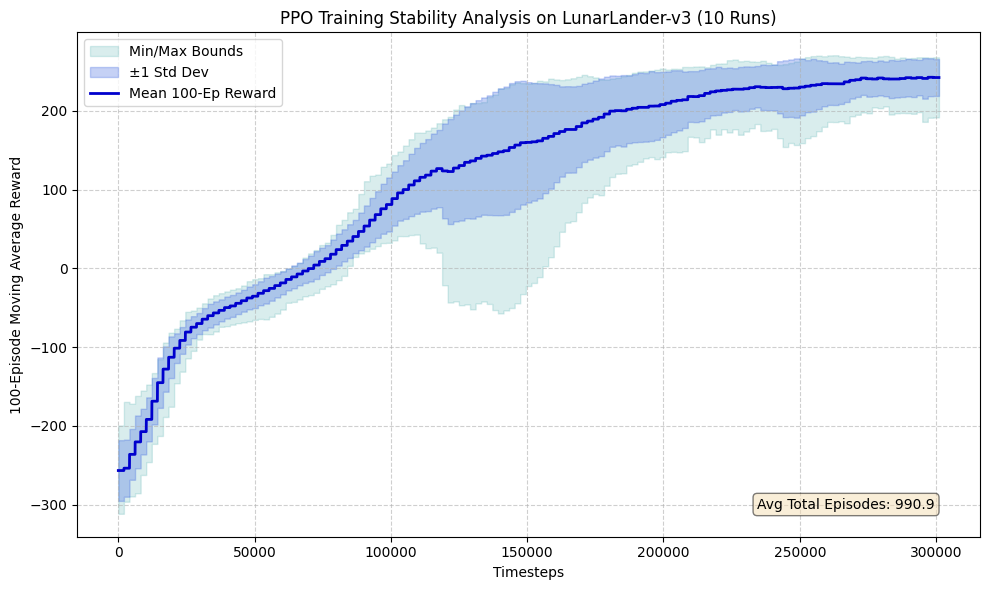

In [9]:
import os

# Configuration
N_RUNS = 10
SAVE_DIR = "./PPO_stability_analysis"

all_runs_logs = []
all_runs_lengths_logs = []

print(f"Loading Stability Analysis data for {N_RUNS} runs from '{SAVE_DIR}'...")

# --- LOAD DATA FROM SAVED ARRAYS ---
for run in range(N_RUNS):
    reward_file = os.path.join(SAVE_DIR, f"run_{run+1}_rewards.npy")
    length_file = os.path.join(SAVE_DIR, f"run_{run+1}_episodes_count.npy")
    
    if os.path.exists(reward_file) and os.path.exists(length_file):
        # Load the step-by-step reward history
        run_history = np.load(reward_file).tolist()
        # Load the scalar episode count (.item() extracts the scalar from the 0D array)
        run_lengths_history = np.load(length_file).item()
        
        all_runs_logs.append(run_history)
        all_runs_lengths_logs.append(run_lengths_history)
        print(f"-> Successfully loaded Run {run + 1} (Total Episodes: {run_lengths_history})")
    else:
        raise FileNotFoundError(f"Missing data files for Run {run + 1}. Please ensure both {reward_file} and {length_file} exist.")

print("\nAll data loaded successfully! Processing metrics and generating stability plot...")

# --- PROCESS METRICS ---
# Convert to a 2D numpy array: shape (N_RUNS, timesteps_logged)
data_matrix = np.array(all_runs_logs)

# Calculate stats across the runs (axis=0)
mean_trend = np.mean(data_matrix, axis=0)
std_trend = np.std(data_matrix, axis=0)
min_trend = np.min(data_matrix, axis=0)
max_trend = np.max(data_matrix, axis=0)

# Since your training loop saved data at EVERY timestep, your effective LOG_FREQ is 1
effective_log_freq = 1
x_axis = np.arange(len(mean_trend)) * effective_log_freq

# --- PLOTTING ---
plt.figure(figsize=(10, 6))

# 1. Fill the Min/Max total range (Light Cyan shadow)
plt.fill_between(
    x_axis, 
    min_trend, 
    max_trend, 
    color="darkcyan", 
    alpha=0.15, 
    label="Min/Max Bounds"
)

# 2. Fill the Standard Deviation shadow (Royal Blue shadow)
plt.fill_between(
    x_axis, 
    mean_trend - std_trend, 
    mean_trend + std_trend, 
    color="royalblue", 
    alpha=0.3, 
    label="±1 Std Dev"
)

# 3. Plot the mean line (Deep Blue line)
plt.plot(x_axis, mean_trend, label="Mean 100-Ep Reward", color="mediumblue", lw=2)

# Graph embellishments
plt.title(f"PPO Training Stability Analysis on LunarLander-v3 ({N_RUNS} Runs)")
plt.xlabel("Timesteps")
plt.ylabel("100-Episode Moving Average Reward")
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.6)

# Display total average episodes completed across all runs as text on the plot
avg_final_episodes = np.mean(all_runs_lengths_logs)
plt.text(0.95, 0.05, f"Avg Total Episodes: {avg_final_episodes:.1f}", 
         transform=plt.gca().transAxes, ha="right", va="bottom",
         bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

plt.tight_layout()
plt.show()